In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import pyFLD as fld
import copy

import temperature_solver as ts

In [2]:
aR = 4 * const.sigma_sb / const.c

# set up the grid and the default arguments to the solver
ri   = fld.grid.get_domain_with_ghosts(0.2, 4, Nx=256, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.2, np.pi/2, Nx=128)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, T=5770*u.K)

In [3]:
def setup_fluid(f, alpha=1e-3, kappa=0, d2g=1):

    s, q, h0 = -0.5, -1, 0.025
    p = s - 0.5 * (q+3)
    R  = grid.R.to('au')
    z  = grid.z.to('au')
    sig_ref = 100 * u.g / u.cm ** 2
    rho_ref = sig_ref / h0 / u.au / np.sqrt(2*np.pi)
    rho = rho_ref * (R/u.au) ** p * np.exp(-0.5 * (z/(h0*R))**2)

    f.set_density(np.ones(grid.shape) * rho * d2g)
    f.set_temperature(np.ones(grid.shape) * 50 * u.K)
    
    f.enroll_kappaR(lambda f: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_kappaP(lambda f: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_kappaPstar(lambda f: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_alpha (lambda f: alpha)
    f.enroll_tau0(lambda f: 0.1 if kappa>0 else 0)
    f.setup()
    
def set_boundaries(Disk):
    # this stuff doesn't need to be changed
    ref, val = fld.grid.BOUNDARY_REFLECTIVE, fld.grid.BOUNDARY_FIXEDVALUE
    bounds = [val, val, val, ref, ref, ref]
    E0     = fld.tools.T_to_Er(10*u.K)
    vals   = [E0, fld.tools.T_to_Er(50*u.K), E0, 0, 0, 0]
    Disk.declare_boundaries(bounds, vals)

def get_analytical_solutions(snaps):
    times_code = []
    Tnum_list  = []

    f0 = snaps[0].fluids[0]
    ts.alpha = f0.get_alpha(f0)
    # index: midplane index, r in au, theta at midplane, dr in au, rho_code, prs_code, T_cgs, t_code
    for snap in snaps:
        data = ts.load_midplane(snap)
        times_code.append(data[7])
        Tnum_list.append(data[6])
    
    data0 = ts.load_midplane(snaps[0]) # initial conditions
    # rho and dx1 are fixed
    tau = ts.compute_tau_midplane(data0[4], data0[3])
    A, B, C, R_au_used = ts.build_coeffs(data0[1], data0[2], tau)
    T_model = ts.integrate_temperature(Tnum_list[0], times_code, A, B, C)  # shape (nsnap, nx1)
    return T_model

In [4]:
default_kwargs = dict(grid=grid, star=star, irradiation='gray', verbose=False, debug=False, gamma=1.43, mu=2.3)
d2g = 1e-3

In [5]:
# time-dependent test for mid viscosity

viscosity, alpha = True, 1e-2
Gas  = fld.fluids.Gas(viscosity=viscosity, name='mid viscosity', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='mid viscosity', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=False, debug=default_kwargs['debug'], name='mid viscosity')
set_boundaries(Disk)

Disk.time = 0 * u.yr
snaps = [copy.deepcopy(Disk)]

dt = 1 * u.yr
t = 0

# perform 50 steps with a timestep of 1 yr
for i in range(1, 21):
    t += dt
    t_ = t.to_value('yr')
    Disk.advance(dt=dt)
    Disk.time = t.to('yr')

    if i % 4 == 0 and i > 0:
        snaps.append(copy.deepcopy(Disk))

T_model = get_analytical_solutions(snaps)

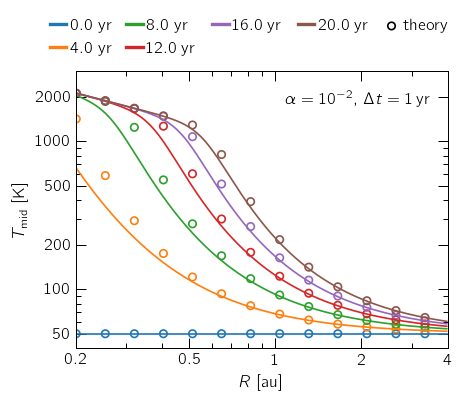

In [6]:
def fmt(x): return x[grid.active][0,-1].to_value('K')

r = grid.x1[grid.act1].to_value('au')

fig, ax = plt.subplots(figsize=(4,3), dpi=120)
slicer = np.s_[::20]

for idx, snap in enumerate(snaps):
    c = f'C{idx}'
    ax.plot(r, fmt(snap.tmp), c=c, label=f'{snap.time:.1f}')
    ax.scatter(r[slicer], T_model[idx][slicer], marker='o', s=20, facecolors='none', edgecolors=c)

ax.scatter([1e10], [1e10], marker='o', s=20, facecolors='none', edgecolors='k', label='theory')
lg = ax.legend(handlelength=1, ncol=5, bbox_to_anchor=[-0.11,1,1.15,1], loc='lower center', mode='expand')
for l in lg.get_lines(): l.set_linewidth(2)

ax.set_yscale('log')
ax.set_ylim(40, 3000)
ax.set_yticks([50, 100, 200, 500, 1000, 2000])
ax.set_yticklabels([f'{s:g}' for s in ax.get_yticks()])

ax.set_xscale('log')
ax.set_xlim(0.2, 4)
ax.set_xticks([0.2, 0.5, 1, 2, 4])
ax.set_xticklabels([f'{s:g}' for s in ax.get_xticks()])

ax.set_xlabel(r'$R$ [au]')
ax.set_ylabel(r'$T_\text{mid}$ [K]')
log_alpha = np.log10(snaps[0].fluids[0].get_alpha(0))
ax.text(0.95, 0.9, r'$\alpha=10^{%d}$, $\Delta t = 1\,$yr'%log_alpha, transform=ax.transAxes, ha='right', va='center')

plt.show()

In [7]:
# try again, but now shrink dt to 0.1 yr -> better match to theoretical solution
# this will take about 10-20s
Gas  = fld.fluids.Gas(viscosity=viscosity, name='mid viscosity', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='mid viscosity', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=False, debug=default_kwargs['debug'], name='disk')
set_boundaries(Disk)

Disk.time = 0 * u.yr
snaps = [copy.deepcopy(Disk)]

dt = 0.1 * u.yr
t = 0

for i in range(1, 201):

    Disk.advance(dt=dt)
    t += dt
    t_ = t.to_value('yr')
    Disk.time = t.to('yr')

    if i % 40 == 0 and i > 0:
        snaps.append(copy.deepcopy(Disk))

T_model = get_analytical_solutions(snaps)

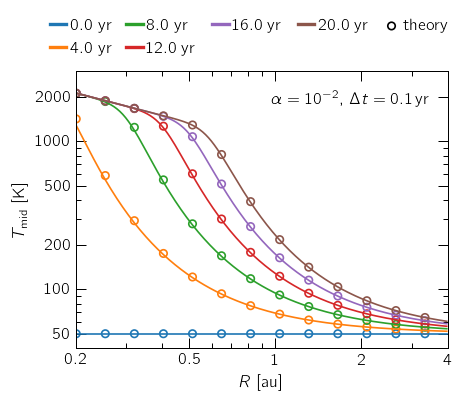

In [8]:
def fmt(x): return x[grid.active][0,-1].to_value('K')

r = grid.x1[grid.act1].to_value('au')

fig, ax = plt.subplots(figsize=(4,3), dpi=120)
slicer = np.s_[::20]

for idx, snap in enumerate(snaps):
    c = f'C{idx}'
    ax.plot(r, fmt(snap.tmp), c=c, label=f'{snap.time:.1f}')
    ax.scatter(r[slicer], T_model[idx][slicer], marker='o', s=20, facecolors='none', edgecolors=c)

ax.scatter([1e10], [1e10], marker='o', s=20, facecolors='none', edgecolors='k', label='theory')
lg = ax.legend(handlelength=1, ncol=5, bbox_to_anchor=[-0.11,1,1.15,1], loc='lower center', mode='expand')
for l in lg.get_lines(): l.set_linewidth(2)

ax.set_yscale('log')
ax.set_ylim(40, 3000)
ax.set_yticks([50, 100, 200, 500, 1000, 2000])
ax.set_yticklabels([f'{s:g}' for s in ax.get_yticks()])

ax.set_xscale('log')
ax.set_xlim(0.2, 4)
ax.set_xticks([0.2, 0.5, 1, 2, 4])
ax.set_xticklabels([f'{s:g}' for s in ax.get_xticks()])

ax.set_xlabel(r'$R$ [au]')
ax.set_ylabel(r'$T_\text{mid}$ [K]')
log_alpha = np.log10(snaps[0].fluids[0].get_alpha(0))
ax.text(0.95, 0.9, r'$\alpha=10^{%d}$, $\Delta t = 0.1\,$yr'%log_alpha, transform=ax.transAxes, ha='right', va='center')

plt.show()